# **Deteksi Spam/Ham - Logistic Regression**

Model prediksi kategori pesan Spam/Ham menggunakan algoritma Logistic Regression.

# 1. Data Preprocessing

### 1.1 Import Library

In [ ]:
# Impor pustaka yang dibutuhkan 
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Silmy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 1.2 Read Dataset

In [ ]:
# Impor dataset
df = pd.read_csv('email.csv')

In [ ]:
# 5 baris teratas
print('5 baris teratas: ')
df.head()

5 baris teratas: 


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# 10 baris acak 
print('10 baris acak: ')
df.sample(10)

10 baris acak: 


,Category,Message
2446,ham,The guy (kadeem) hasn't been selling since the...
760,ham,"Call me when you/carlos is/are here, my phone'..."
1067,ham,Once free call me sir. I am waiting for you.
2666,ham,R u meeting da ge at nite tmr?
3041,ham,One day a crab was running on the sea shore..T...
4216,ham,No dear i was sleeping :-P
985,ham,Yo guess what I just dropped
2275,ham,Think I could stop by in like an hour or so? M...
326,ham,No calls..messages..missed calls
5226,ham,Prabha..i'm soryda..realy..frm heart i'm sory


In [ ]:
# Dimensi dataset
print('Jumlah baris:', df.shape[0])
print('Jumlah fitur:', df.shape[1])

Jumlah baris: 5573
Jumlah fitur: 2


In [ ]:
# Ringkasan informasi
print('Ringkasan informasi dataset:')
df.info()

Ringkasan informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
# Ringkasan statistik
print('Ringkasan statistik dataset:')
df.describe(include='object')

Ringkasan statistik dataset:


,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


In [ ]:
# Cek nama kolom dalam dataset 
print('Nama kolom dalam dataset:', df.columns.tolist())

Nama kolom dalam dataset: ['Category', 'Message']


In [ ]:
# Cek nilai unik pada target
print('Nilai unik pada target:', df['Category'].unique().tolist())

Nilai unik pada target: ['ham', 'spam', '{"mode":"full"']


In [ ]:
# Penyebaran target
print('Penyebaran target:')
df['Category'].value_counts()

Penyebaran target:


Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

### 1.3 Data Cleaning

#### 1.3.1 Data Anomali

In [ ]:
# Cek data anomali pada kolom 'Category'
df['Category'].unique()

array(['ham', 'spam', '{"mode":"full"'], dtype=object)

Terdapat data anomali yaitu "mode":"full" yang menyimpang dari data mayoritas dan bukan termasuk kategori pesan.

In [ ]:
# Menangani data anomali
df = df[df['Category'].isin(['ham', 'spam'])]


In [ ]:
df['Category'].unique()

array(['ham', 'spam'], dtype=object)

#### 1.3.2 Missing Value

In [ ]:
# Cek nilai kosong
print('Jumlah nilai kosong:')
df.isnull().sum()

Jumlah nilai kosong:


Category    0
Message     0
dtype: int64

#### 1.3.3 Data Duplikat

In [ ]:
# Jumlah data duplikat
print('Jumlah data duplikat:', df.duplicated().sum())

Jumlah data duplikat: 415


In [ ]:
# Cek jumlah duplikat pada baris duplikat
df.groupby(['Category', 'Message']).size().sort_values(ascending=False).head()

Category  Message                                                                                                                                                            
ham       Sorry, I'll call later                                                                                                                                                 30
          I cant pick the phone right now. Pls send a message                                                                                                                    12
          Ok...                                                                                                                                                                  10
          Okie                                                                                                                                                                    4
          Say this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,CLEAN MY HEART WITH YOUR BLOOD.Send this to Te

Kami tidak menangani data duplikat dengan menghapusnya, karena itu masih merepresentasikan dunia nyata.

### Encoding

Target diubah menjadi numerik menggunakan tekni mapping, dengan keterangan sebagai berikut:
- 0 : Pesan Ham
- 1 : Pesan Spam

In [ ]:
# Encoding menggunakan teknik mapping
df['Category'] = df['Category'].map({'ham':0, 'spam':1})

In [ ]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 2. Exploratory Data Analysis

### 2.1 Distribusi Data

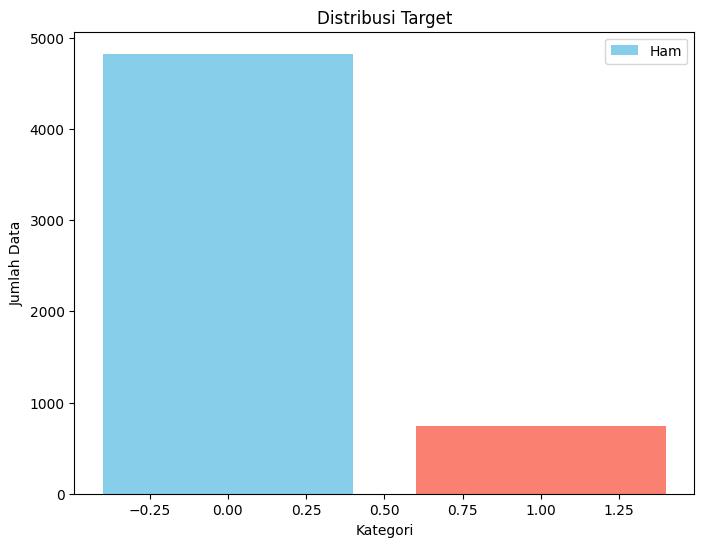

In [ ]:
counts = df['Category'].value_counts().sort_index()

plt.figure(figsize=(8,6))
plt.bar(counts.index, counts.values, color=['skyblue', 'salmon'])

plt.title('Distribusi Target')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Data')

plt.legend(['Ham', 'Spam'])
plt.show()


Penyebaran target pada dataset immbalance. Dimana,  pesan dengan kategori ham memiliki jumlah hampir 5000 pesan, sedangkan pesan dengan kategori spam hanya memiliki jumlah tidak lebih dari 1000 pesan.

Text(0.5, 1.0, 'Presentase Distirbusi Target')

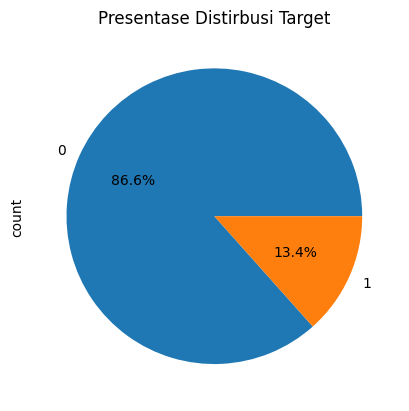

In [ ]:
# Pie Cart
counts = df['Category'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Presentase Distirbusi Target')

Dalam kasus dunia nyata, distribusi pesan ham mendominasi daripada spam, adalah hal yang wajar. Sehingga, kami tidak melakukan resampling data.

In [ ]:
df['Message_length'] = df['Message'].apply(len)
df.head()

,Category,Message,Message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


## 3. Modeling

### 3.1 Fitur Independent dan Dependent

In [ ]:
X = df['Message'] # Independent
y = df['Category'] # Dependent


### 3.2 NLP

In [ ]:
# Case Normalization & Text Cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Message'] = df['Message'].apply(clean_text)

In [ ]:
# Stop words, Stemming, Tokenization, Remove Punctuation and Numbers
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # Menghapus karakter yang bukan huruf
    words = text.split() # Memisah kata
    words = [w for w in words if w not in stop_words]
    words = [stemmer.stem(w) for w in words] # Memotong akhir kata menjadi kata dasar
    return ' '.join(words)

df['clean_message'] = df['Message'].apply(clean_text)


In [ ]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words] # Mengubah akhir kata menjadi kata dasar
    return ' '.join(words)

In [ ]:
from nltk.corpus import words, wordnet
from nltk.metrics import edit_distance
import nltk
nltk.download('words')
nltk.download('wordnet')


word_list = set(words.words())
def correct_word(word):
    if wordnet.synsets(word):
        return word  
    candidates = [w for w in word_list if edit_distance(word, w) == 1]
    return candidates[0] if candidates else word

[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Silmy\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Silmy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# Membuat directory
vocab = {}

for msg in df['clean_message']:
    for word in msg.split():
        if word not in vocab:
            vocab[word] = len(vocab)


In [ ]:

X = np.zeros((len(df), len(vocab)))

for i, msg in enumerate(df['clean_message']):
    for word in msg.split():
        if word in vocab:
            X[i, vocab[word]] += 1


In [ ]:
y = df['Category'].values.reshape(-1, 1)


In [ ]:
# TF normalization -> Menghitung seberapa sering kata muncul dalam df
TF = np.zeros_like(X, dtype=float)

for i in range(X.shape[0]):          # tiap dokumen
    max_freq = np.max(X[i])
    if max_freq > 0:
        TF[i] = X[i] / max_freq


In [ ]:
N = X.shape[0]  # jumlah dokumen

# document frequency
df_t = np.count_nonzero(X > 0, axis=0)

# IDF
IDF = np.log(N / (df_t + 1))



In [ ]:
TF_IDF = TF * IDF


In [ ]:
X_tfidf = TF_IDF

split = int(0.8 * len(X_tfidf))

X_train = X_tfidf[:split]
X_test  = X_tfidf[split:]

y_train = y[:split]
y_test  = y[split:]


In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
lr = 0.01
epochs = 2000

weights = np.zeros((X_train.shape[1], 1))
bias = 0

for _ in range(epochs):
    z = np.dot(X_train, weights) + bias
    y_hat = sigmoid(z)

    dw = np.dot(X_train.T, (y_hat - y_train)) / len(y_train)
    db = np.mean(y_hat - y_train)

    weights -= lr * dw
    bias -= lr * db


In [ ]:
def predict(X, weights, bias, threshold=0.2):
    probs = sigmoid(np.dot(X, weights) + bias)
    return (probs >= threshold).astype(int)

y_pred = predict(X_test, weights, bias)


In [ ]:
np.unique(y_pred, return_counts=True)


(array([0, 1]), array([945, 170]))

## 4. Evaluasi

In [ ]:
TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == 0) & (y_pred == 0))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))

In [ ]:
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("Accuracy :", accuracy)

Precision: 0.8058823529411765
Recall   : 0.9448275862068966
F1-score : 0.8698412698412699
Accuracy : 0.9632286995515695


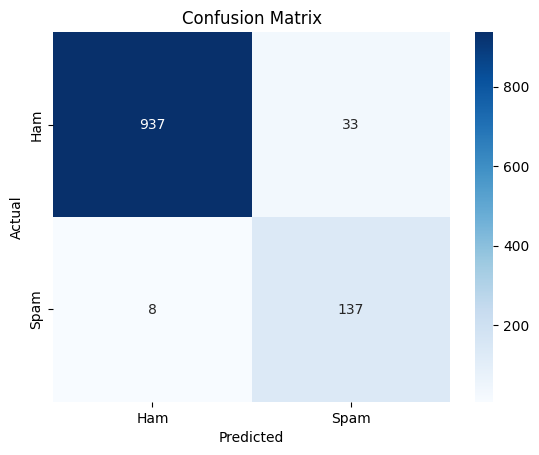

In [ ]:
cm = np.array([[TN, FP],
               [FN, TP]])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## 5. Visualisasi

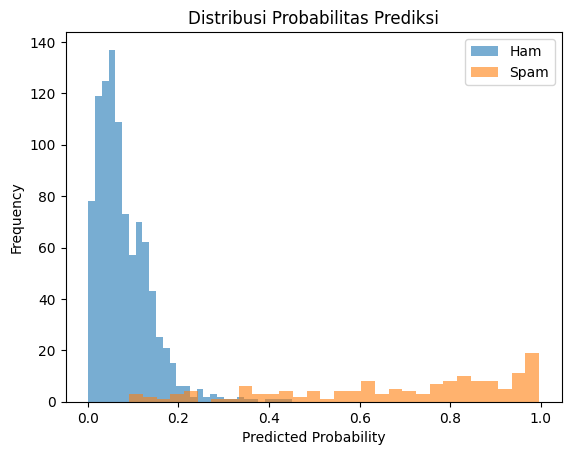

In [ ]:
probs = sigmoid(np.dot(X_test, weights) + bias)

plt.hist(probs[y_test.flatten()==0], bins=30, alpha=0.6, label='Ham')
plt.hist(probs[y_test.flatten()==1], bins=30, alpha=0.6, label='Spam')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribusi Probabilitas Prediksi')
plt.show()
